# LTE Throughput Degradation — Incidents-Level Root Cause Analysis

This notebook is built entirely on `rca_anomaly_incidents_full_compact.json` — the aggregated,
incident-level dataset (1,382 incidents) — rather than the row-level drive-test CSV used in earlier
versions of this project's analysis. Every classification below is driven directly by the project's
shared JSON knowledge base (`causes.json`, `kpi_rules.json`, `solutions.json`): thresholds are read from
`kpi_rules.json` at runtime, nothing is hardcoded here.


## 0. Setup


In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.edgecolor': '#333333', 'axes.labelcolor': '#333333',
    'text.color': '#333333', 'xtick.color': '#333333', 'ytick.color': '#333333',
    'axes.grid': True, 'grid.alpha': 0.25, 'grid.linestyle': '--',
    'font.size': 10.5,
})

COLORS = {
    'blue': '#3B6FA0', 'orange': '#D9822B', 'red': '#C1443C', 'green': '#4E8B5C',
    'purple': '#7A5C9E', 'grey': '#8C8C8C', 'teal': '#3E8E8E', 'gold': '#C9A227',
    'critical': '#C1443C', 'high': '#D9822B', 'medium': '#C9A227', 'coral': '#D9724A',
}

causes = json.load(open('causes.json'))
kpi_rules = json.load(open('kpi_rules.json'))
solutions = {s['id']: s for s in json.load(open('solutions.json'))['solutions']}
incidents = json.load(open('rca_anomaly_incidents_full_compact.json'))
print(f"Loaded {len(incidents)} incidents, {len(kpi_rules['rules'])} KPI rules, {len(solutions)} solution entries")

id_to_cause, id_to_subcat = {}, {}
for cat in causes['priority_categories']:
    for sc in cat['subcategories']:
        for c in sc['causes_list']:
            id_to_cause[c['id']] = c
            id_to_subcat[c['id']] = {"category": cat['category'], "subcategory": sc['subcategory'], "parent_id": sc['parent_id']}


Loaded 1382 incidents, 14 KPI rules, 14 solution entries


## 1. Dataset Overview


In [2]:
def gg(d, path, default=None):
    cur = d
    for p in path.split('.'):
        if cur is None: return default
        cur = cur.get(p) if isinstance(cur, dict) else default
        if cur is None: return default
    return cur

def nn(x): return isinstance(x, (int, float))

start_times = [i.get('start_time') for i in incidents if i.get('start_time')]
print(f"Total incidents: {len(incidents)}")
print(f"Date range: {min(start_times)} to {max(start_times)}")
print(f"Unique serving cells: {len(set(i.get('serving_cell_key') for i in incidents))}")
print(f"Unique sessions: {len(set(i.get('session_id') for i in incidents))}")
print(f"Total underlying drive-test rows represented: {sum(i.get('rows', 0) for i in incidents):,}")


Total incidents: 1382
Date range: 2025-08-26 23:37:42+02:00 to 2025-08-29 00:36:37+02:00
Unique serving cells: 423
Unique sessions: 254
Total underlying drive-test rows represented: 2,824


## 2. Data Quality & Field Availability

This dataset carries `radio_kpis`, `resource_kpis`, `throughput`, `ca_context`, `statistical_evidence`,
and `rca_required_kpis` (mobility/RACH/MIMO) per incident — a genuine, wide field set. What it does
**not** carry: `active_user_count`, `cell_traffic_volume`, per-band CA configuration, or any OSS
alarm/hardware telemetry. Every cause in `causes.json` that needs one of those is explicitly marked
`kpi_computable: false` and will never fire here — that's documented, not a silent gap.


In [3]:
not_computable_count = sum(1 for cat in causes['priority_categories'] for sc in cat['subcategories']
                            for c in sc['causes_list'] if not c.get('kpi_computable', True))
total_causes = sum(1 for cat in causes['priority_categories'] for sc in cat['subcategories'] for c in sc['causes_list'])
print(f"{not_computable_count} of {total_causes} defined causes are NOT_COMPUTABLE from any dataset in this project.")

missing_field_rate = {
    'radio_kpis.rsrp_median_dbm': sum(1 for i in incidents if gg(i,'radio_kpis.rsrp_median_dbm') is None),
    'throughput.expected_median_mbps': sum(1 for i in incidents if gg(i,'throughput.expected_median_mbps') is None),
    'ca_context.ca_active': sum(1 for i in incidents if gg(i,'ca_context.ca_active') is None),
    'rca_required_kpis.lte_rank': sum(1 for i in incidents if gg(i,'rca_required_kpis.lte_rank') is None),
}
for k,v in missing_field_rate.items():
    print(f"  Missing '{k}': {v}/{len(incidents)} ({v/len(incidents)*100:.1f}%)")


23 of 71 defined causes are NOT_COMPUTABLE from any dataset in this project.
  Missing 'radio_kpis.rsrp_median_dbm': 0/1382 (0.0%)
  Missing 'throughput.expected_median_mbps': 0/1382 (0.0%)
  Missing 'ca_context.ca_active': 0/1382 (0.0%)
  Missing 'rca_required_kpis.lte_rank': 46/1382 (3.3%)


## 3. KPI Health Analysis


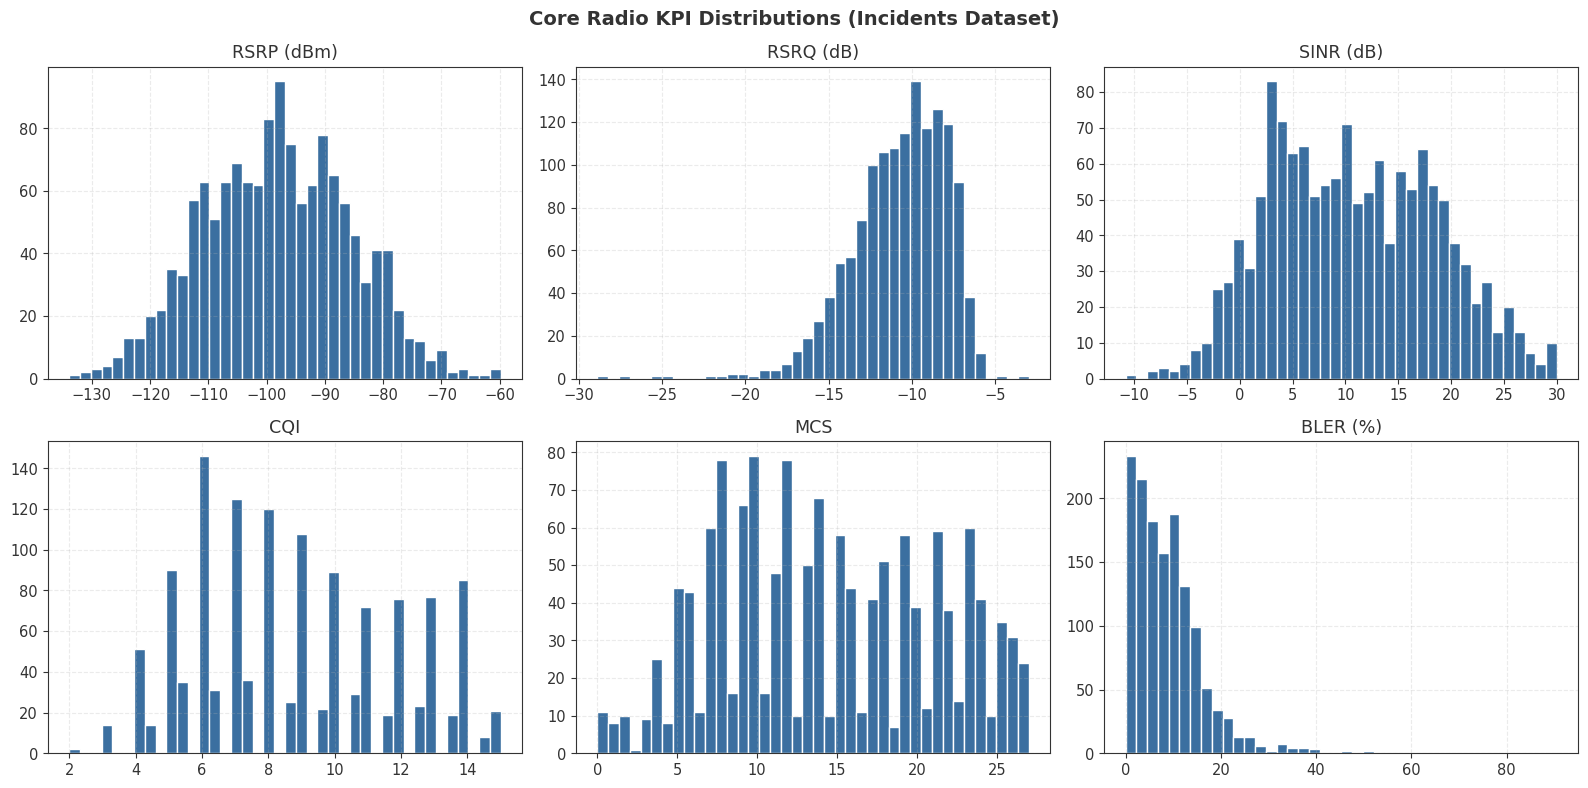

In [4]:
kpi_fields = {
    'RSRP (dBm)': 'radio_kpis.rsrp_median_dbm', 'RSRQ (dB)': 'radio_kpis.rsrq_median_db',
    'SINR (dB)': 'radio_kpis.sinr_median_db', 'CQI': 'radio_kpis.cqi_median',
    'MCS': 'radio_kpis.mcs_median', 'BLER (%)': 'radio_kpis.bler_median_pct',
}
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Core Radio KPI Distributions (Incidents Dataset)', fontsize=14, fontweight='bold')
for ax, (label, path) in zip(axes.flat, kpi_fields.items()):
    vals = [gg(i, path) for i in incidents]
    vals = [v for v in vals if v is not None]
    ax.hist(vals, bins=40, color=COLORS['blue'], edgecolor='white')
    ax.set_title(label)
plt.tight_layout(); plt.show()


**Finding:** distributions here are medians of already-flagged anomaly windows, so they skew worse
than a general population would — consistent with what Section 14 of the CSV-based analysis found for
the row-level data.


## 4. Coverage Analysis (Weak Serving Cell)


Incidents with RSRP < -110 dBm (Poor coverage band): 268 (19.4%)


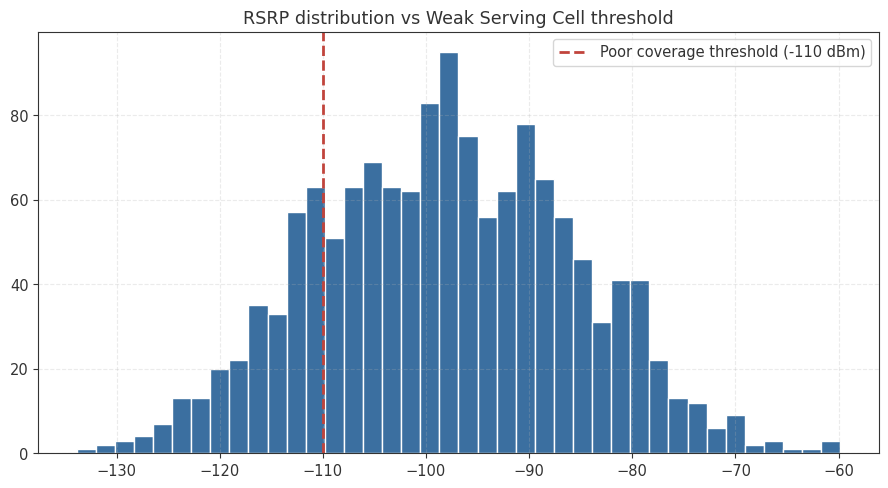

In [5]:
rsrp_vals = pd.Series([gg(i,'radio_kpis.rsrp_median_dbm') for i in incidents]).dropna()
weak_coverage = rsrp_vals < -110
print(f"Incidents with RSRP < -110 dBm (Poor coverage band): {weak_coverage.sum()} ({weak_coverage.mean()*100:.1f}%)")

fig, ax = plt.subplots(figsize=(9,5))
ax.hist(rsrp_vals, bins=40, color=COLORS['blue'], edgecolor='white')
ax.axvline(-110, color=COLORS['red'], ls='--', lw=2, label='Poor coverage threshold (-110 dBm)')
ax.set_title('RSRP distribution vs Weak Serving Cell threshold')
ax.legend(); plt.tight_layout(); plt.show()


## 5. Interference Analysis


Incidents with RSRP OK but SINR < 0 dB (Interference signature): 28 (2.0%)


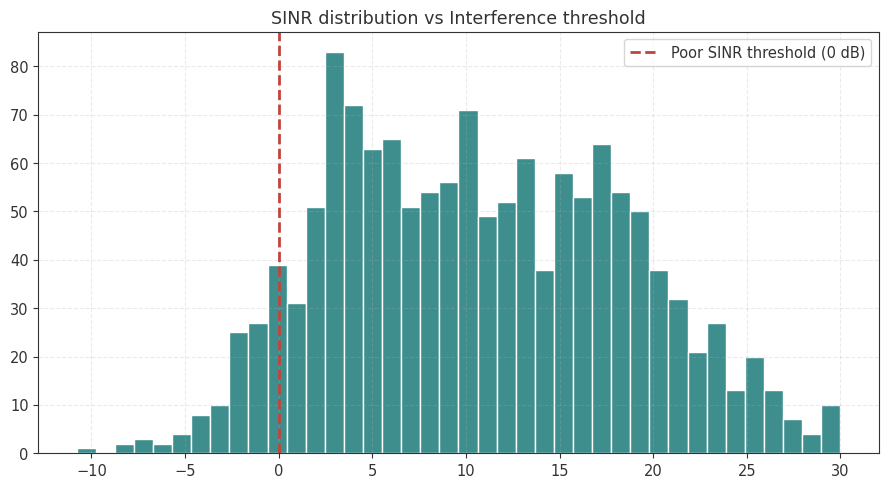

In [6]:
sinr_vals = pd.Series([gg(i,'radio_kpis.sinr_median_db') for i in incidents]).dropna()
rsrp_ok_sinr_poor = sum(1 for i in incidents if nn(gg(i,'radio_kpis.rsrp_median_dbm')) and gg(i,'radio_kpis.rsrp_median_dbm')>=-110
                         and nn(gg(i,'radio_kpis.sinr_median_db')) and gg(i,'radio_kpis.sinr_median_db')<0)
print(f"Incidents with RSRP OK but SINR < 0 dB (Interference signature): {rsrp_ok_sinr_poor} ({rsrp_ok_sinr_poor/len(incidents)*100:.1f}%)")

fig, ax = plt.subplots(figsize=(9,5))
ax.hist(sinr_vals, bins=40, color=COLORS['teal'], edgecolor='white')
ax.axvline(0, color=COLORS['red'], ls='--', lw=2, label='Poor SINR threshold (0 dB)')
ax.set_title('SINR distribution vs Interference threshold')
ax.legend(); plt.tight_layout(); plt.show()


## 6. Congestion Analysis


Incidents with confirmed RB-relevant demand: 674 (48.8%)


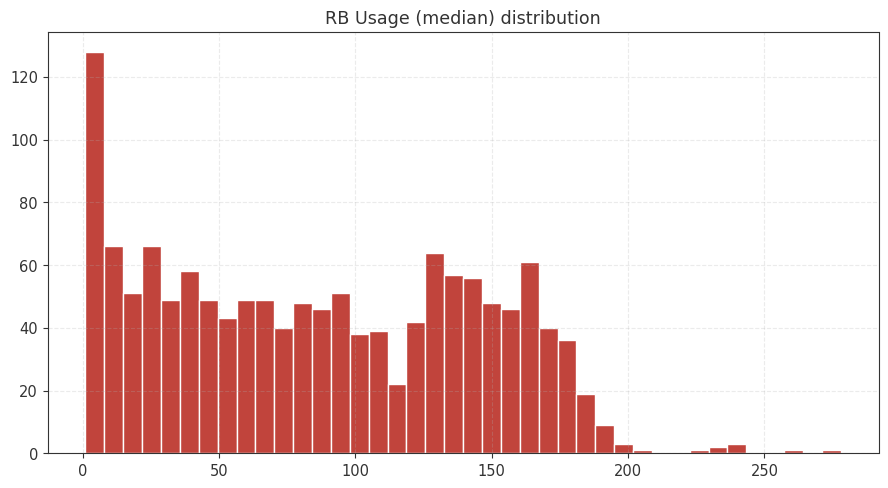

In [7]:
rb_usage = pd.Series([gg(i,'resource_kpis.rb_usage_median') for i in incidents]).dropna()
demand_confirmed = [ (gg(i,'detection_case')=='rb_conditioned_expected_underperformance') or bool(gg(i,'resource_kpis.rb_medium_or_high_usage', False)) for i in incidents ]
print(f"Incidents with confirmed RB-relevant demand: {sum(demand_confirmed)} ({sum(demand_confirmed)/len(incidents)*100:.1f}%)")

fig, ax = plt.subplots(figsize=(9,5))
ax.hist(rb_usage, bins=40, color=COLORS['red'], edgecolor='white')
ax.set_title('RB Usage (median) distribution')
plt.tight_layout(); plt.show()


## 7. Carrier Aggregation Analysis


CA active: 1166 (84.4%)


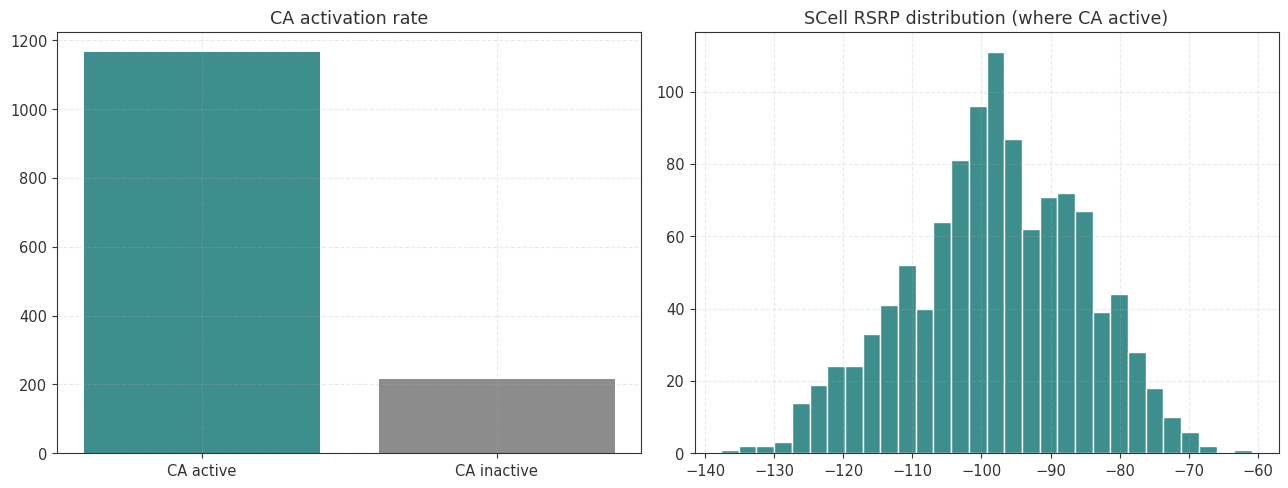

In [8]:
ca_active = [bool(gg(i,'ca_context.ca_active', False)) for i in incidents]
print(f"CA active: {sum(ca_active)} ({sum(ca_active)/len(incidents)*100:.1f}%)")
scell_rsrp = pd.Series([gg(i,'ca_context.scell1_rsrp_median_dbm') for i in incidents]).dropna()

fig, axes = plt.subplots(1,2, figsize=(13,5))
axes[0].bar(['CA active','CA inactive'], [sum(ca_active), len(incidents)-sum(ca_active)], color=[COLORS['teal'],COLORS['grey']])
axes[0].set_title('CA activation rate')
axes[1].hist(scell_rsrp, bins=30, color=COLORS['teal'], edgecolor='white')
axes[1].set_title('SCell RSRP distribution (where CA active)')
plt.tight_layout(); plt.show()


## 8. Mobility Analysis


Near a handover event: 744 (53.8%)
Near a RACH failure: 117 (8.5%)


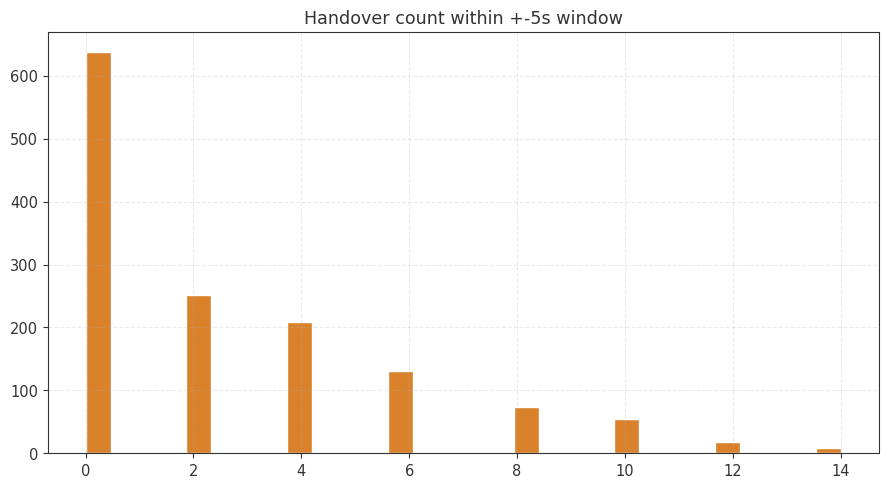

In [9]:
near_ho = [bool(gg(i,'rca_required_kpis.near_handover_mobility_flag', False)) for i in incidents]
near_rach = [bool(gg(i,'rca_required_kpis.near_rach_failure_flag', False)) for i in incidents]
print(f"Near a handover event: {sum(near_ho)} ({sum(near_ho)/len(incidents)*100:.1f}%)")
print(f"Near a RACH failure: {sum(near_rach)} ({sum(near_rach)/len(incidents)*100:.1f}%)")

ho_count = pd.Series([gg(i,'rca_required_kpis.handover_mobility_count_pm5s') for i in incidents]).dropna()
fig, ax = plt.subplots(figsize=(9,5))
ax.hist(ho_count, bins=30, color=COLORS['orange'], edgecolor='white')
ax.set_title('Handover count within +-5s window')
plt.tight_layout(); plt.show()


## 9. MIMO Analysis


In [10]:
rank_vals = pd.Series([gg(i,'rca_required_kpis.lte_rank') for i in incidents]).dropna()
rank1_good_sinr = sum(1 for i in incidents if gg(i,'rca_required_kpis.lte_rank')==1
                       and nn(gg(i,'radio_kpis.sinr_median_db')) and gg(i,'radio_kpis.sinr_median_db')>=15)
print(f"Rank distribution:\n{rank_vals.value_counts().sort_index()}")
print(f"\nRank==1 despite SINR>=15dB (rank-fallback signature): {rank1_good_sinr}")


Rank distribution:
1.0    495
1.5    161
2.0    680
Name: count, dtype: int64

Rank==1 despite SINR>=15dB (rank-fallback signature): 68


## 10. Engineering Cause Analysis — driven entirely by `kpi_rules.json`

Generic condition evaluator + two-function classifier (priorities 1-4, then 5-6), reading every
threshold from `kpi_rules.json` at runtime -- identical engine to `classify_incidents.py`.


In [11]:
def evaluate_condition(cond, f):
    if cond.get('not_computable'): return False
    if 'all' in cond: return all(evaluate_condition(c, f) for c in cond['all'])
    if 'any' in cond: return any(evaluate_condition(c, f) for c in cond['any'])
    if 'not' in cond: return not evaluate_condition(cond['not'], f)
    field, op, value = cond['field'], cond['op'], cond['value']
    fv = f.get(field)
    if fv is None: return False
    if op == '==': return fv == value
    if op == '!=': return fv != value
    if op == '<':  return fv < value
    if op == '<=': return fv <= value
    if op == '>':  return fv > value
    if op == '>=': return fv >= value
    if op == 'in': return fv in value
    raise ValueError(f"unknown operator {op}")

def evaluate_gate(rule, f):
    logic = rule.get('gate_logic', 'ALL')
    conds = rule['gate_conditions']
    return all(evaluate_condition(c, f) for c in conds) if logic=='ALL' else any(evaluate_condition(c, f) for c in conds)

def evaluate_supporting_evidence(rule, f):
    return [ev['id'] for ev in rule.get('supporting_evidence', []) if evaluate_condition(ev['detection_conditions'], f)]

def extract_incident(rec):
    f = {}
    f['rsrp'] = gg(rec, 'radio_kpis.rsrp_median_dbm'); f['rsrq'] = gg(rec, 'radio_kpis.rsrq_median_db')
    f['sinr'] = gg(rec, 'radio_kpis.sinr_median_db'); f['cqi'] = gg(rec, 'radio_kpis.cqi_median')
    f['mcs'] = gg(rec, 'radio_kpis.mcs_median'); f['bler'] = gg(rec, 'radio_kpis.bler_median_pct')
    f['rb_usage'] = gg(rec, 'resource_kpis.rb_usage_median'); f['tp_per_rb'] = gg(rec, 'resource_kpis.throughput_per_rb_median')
    f['rb_med_high'] = gg(rec, 'resource_kpis.rb_medium_or_high_usage', False)
    f['actual_tp'] = gg(rec, 'throughput.actual_median_mbps'); f['expected_tp'] = gg(rec, 'throughput.expected_median_mbps')
    f['ca_active'] = gg(rec, 'ca_context.ca_active', False); f['carrier_count'] = gg(rec, 'ca_context.carrier_count_median')
    f['scell_rsrp'] = gg(rec, 'ca_context.scell1_rsrp_median_dbm'); f['scell_sinr'] = gg(rec, 'ca_context.scell1_sinr_median_db')
    f['scell_cqi'] = gg(rec, 'ca_context.scell1_cqi_median'); f['scell_bler'] = gg(rec, 'ca_context.scell1_bler_median_pct')
    f['temporal_drop'] = gg(rec, 'statistical_evidence.temporal_drop', False)
    f['sustained_window'] = gg(rec, 'statistical_evidence.sustained_window', False)
    f['low_tail_consensus'] = gg(rec, 'statistical_evidence.low_tail_consensus', False)
    f['detection_case'] = rec.get('detection_case'); f['severity'] = rec.get('severity')
    f['cell_prb_util'] = gg(rec, 'rca_required_kpis.cell_prb_utilization_pct')
    f['near_ho'] = bool(gg(rec, 'rca_required_kpis.near_handover_mobility_flag', False))
    f['near_rach_fail'] = bool(gg(rec, 'rca_required_kpis.near_rach_failure_flag', False))
    f['neighbor_avail'] = gg(rec, 'rca_required_kpis.neighbor_cell_availability')
    f['rank'] = gg(rec, 'rca_required_kpis.lte_rank'); f['ue_speed'] = gg(rec, 'rca_required_kpis.ue_speed_kmh')
    f['gap_rsrp'] = gg(rec, 'rca_required_kpis.serving_minus_best_neighbor_rsrp')
    f['ho_count_pm5s'] = gg(rec, 'rca_required_kpis.handover_mobility_count_pm5s')
    f['ho_dwell'] = gg(rec, 'rca_required_kpis.ho_dwell_time_s')
    f['cell_median_tp'] = gg(rec, 'cell_performance_context.cell_median_tp_mbps')
    f['cell_bad_rank'] = gg(rec, 'cell_performance_context.cell_bad_rank', False)
    rach_reason = gg(rec, 'rca_required_kpis.rach_reason', [])
    f['rlf_present'] = isinstance(rach_reason, list) and 'Radio link Failure' in rach_reason
    f['demand_confirmed'] = (f['detection_case']=='rb_conditioned_expected_underperformance') or bool(f['rb_med_high'])
    f['demand_confirmed_broad'] = nn(f['expected_tp']) and f['expected_tp'] > 0.1
    f['bad_session'] = bool(f['sustained_window']) and bool(f['low_tail_consensus'])
    f['fallback'] = True
    f['underperform_80pct'] = nn(f['expected_tp']) and nn(f['actual_tp']) and f['actual_tp'] < 0.8*f['expected_tp']
    own_radio_bad = (nn(f['rsrp']) and f['rsrp']<-110) or (nn(f['sinr']) and f['sinr']<0)
    f['own_radio_normal'] = (nn(f['rsrp']) and f['rsrp']>=-110) and (nn(f['sinr']) and f['sinr']>=0) and not own_radio_bad
    f['mimo_pattern'] = nn(f['sinr']) and f['sinr']>=15 and nn(f['rank']) and f['rank']==1
    f['not_mobility'] = not f['near_ho']; f['not_mimo'] = not f['mimo_pattern']
    f['near_zero_tp'] = nn(f['actual_tp']) and f['actual_tp'] < 0.05
    f['session_collapse'] = bool(f['temporal_drop']) and bool(f['bad_session'])
    f['cell_prb_util_spike'] = nn(f['cell_prb_util']) and f['cell_prb_util'] >= 80
    f['neighbor_avail_drop'] = nn(f['neighbor_avail']) and f['neighbor_avail'] < 80
    return f


In [12]:
def classify_priority_1_to_4(f):
    for rule in kpi_rules['rules']:
        if not (1 <= rule['priority'] <= 4): continue
        if not evaluate_gate(rule, f): continue
        if 'alternatives' in rule:
            for alt in rule['alternatives']:
                if all(evaluate_condition(c, f) for c in alt['gate_conditions']):
                    return (alt['id'], evaluate_supporting_evidence(rule, f))
            continue
        return (rule['parent_id'], evaluate_supporting_evidence(rule, f))
    return (None, [])

def classify_priority_5_to_6(f):
    for rule in kpi_rules['rules']:
        if not (5 <= rule['priority'] <= 6): continue
        if evaluate_gate(rule, f):
            return (rule['parent_id'], evaluate_supporting_evidence(rule, f))
    return (None, [])

def classify_fallback(f):
    for rule in kpi_rules['rules']:
        if rule['priority']==7 and rule['parent_id']=='C14' and evaluate_gate(rule, f):
            return 'C14'
    return 'C15'

def classify_incident(rec):
    f = extract_incident(rec)
    if not f['demand_confirmed_broad']:
        cid, ev = 'C15', []
    else:
        cid, ev = classify_priority_1_to_4(f)
        if cid is None: cid, ev = classify_priority_5_to_6(f)
        if cid is None: cid, ev = classify_fallback(f), []
    subcat = id_to_subcat[cid]
    problem_name = subcat['subcategory'] if cid==subcat['parent_id'] else f"{subcat['subcategory']} - {id_to_cause[cid]['name']}"
    return cid, problem_name, ev, f

classification_results = [classify_incident(rec) for rec in incidents]
print(f"Classified {len(classification_results)} incidents")


Classified 1382 incidents


## 11. Root Cause Distribution


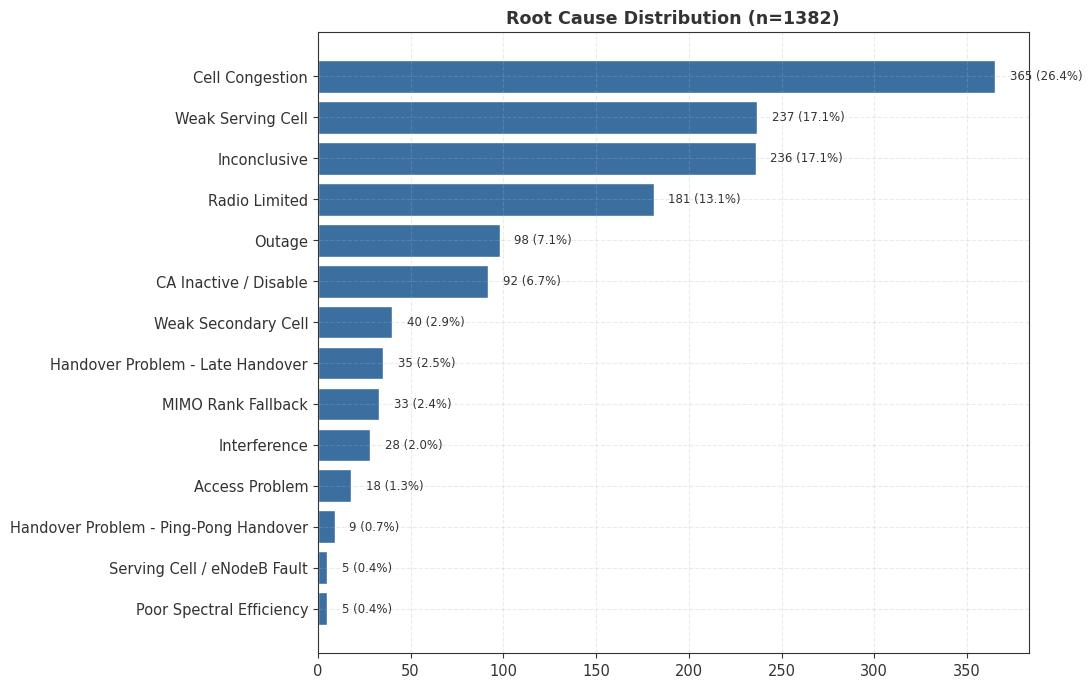

  Cell Congestion: 365
  Weak Serving Cell: 237
  Inconclusive: 236
  Radio Limited: 181
  Outage: 98
  CA Inactive / Disable: 92
  Weak Secondary Cell: 40
  Handover Problem - Late Handover: 35
  MIMO Rank Fallback: 33
  Interference: 28
  Access Problem: 18
  Handover Problem - Ping-Pong Handover: 9
  Serving Cell / eNodeB Fault: 5
  Poor Spectral Efficiency: 5


In [13]:
problem_names = [r[1] for r in classification_results]
dist = Counter(problem_names)

fig, ax = plt.subplots(figsize=(11, 7))
order = [k for k,_ in dist.most_common()]
values = [dist[k] for k in order]
ax.barh(order, values, color=COLORS['blue'], edgecolor='white')
ax.invert_yaxis()
ax.set_title(f'Root Cause Distribution (n={len(incidents)})', fontweight='bold')
for i,v in enumerate(values):
    ax.text(v+8, i, f'{v} ({v/len(incidents)*100:.1f}%)', va='center', fontsize=8.5)
plt.tight_layout(); plt.show()
for name, n in dist.most_common(): print(f"  {name}: {n}")


## 12. Supporting-Evidence Co-occurrence

Which pieces of supporting evidence tend to fire together, across all classified incidents.


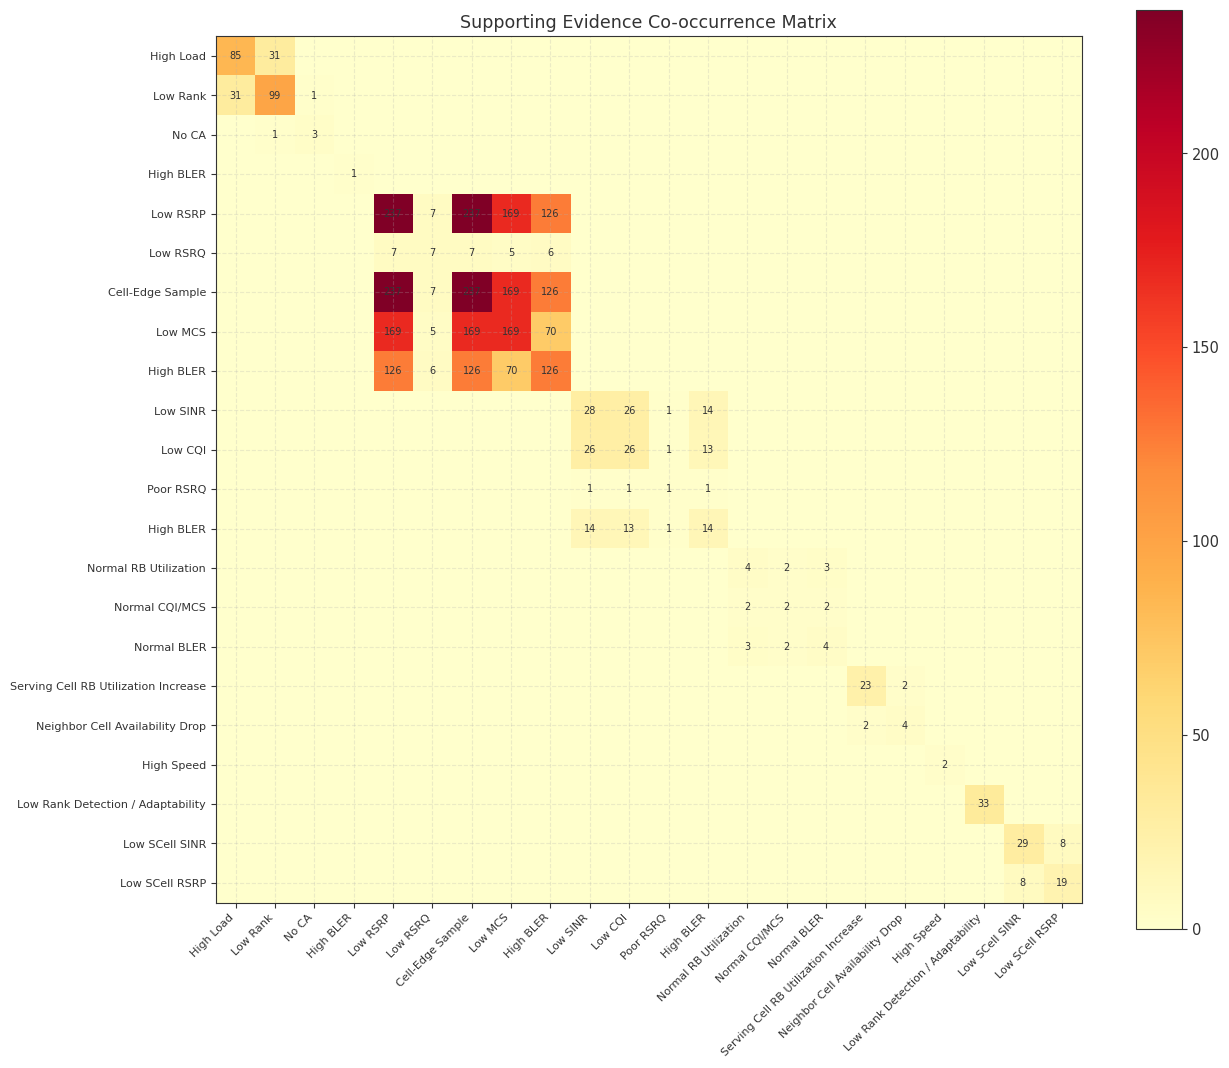

In [14]:
all_evidence_ids = sorted(set(eid for r in classification_results for eid in r[2]))
evidence_names = [id_to_cause[e]['name'] for e in all_evidence_ids]

co_occ = pd.DataFrame(0, index=all_evidence_ids, columns=all_evidence_ids)
for _, _, ev, _ in classification_results:
    for e1 in ev:
        for e2 in ev:
            co_occ.loc[e1, e2] += 1

if len(all_evidence_ids) > 0:
    fig, ax = plt.subplots(figsize=(max(8, len(all_evidence_ids)*0.6), max(6, len(all_evidence_ids)*0.5)))
    im = ax.imshow(co_occ.values, cmap='YlOrRd')
    ax.set_xticks(range(len(all_evidence_ids))); ax.set_xticklabels(evidence_names, rotation=45, ha='right', fontsize=8)
    ax.set_yticks(range(len(all_evidence_ids))); ax.set_yticklabels(evidence_names, fontsize=8)
    for i in range(len(all_evidence_ids)):
        for j in range(len(all_evidence_ids)):
            v = co_occ.values[i,j]
            if v > 0: ax.text(j,i,int(v),ha='center',va='center',fontsize=7)
    ax.set_title('Supporting Evidence Co-occurrence Matrix')
    plt.colorbar(im)
    plt.tight_layout(); plt.show()
else:
    print("No supporting evidence recorded across any classified incident.")


## 13. Severity & Detection Method Landscape


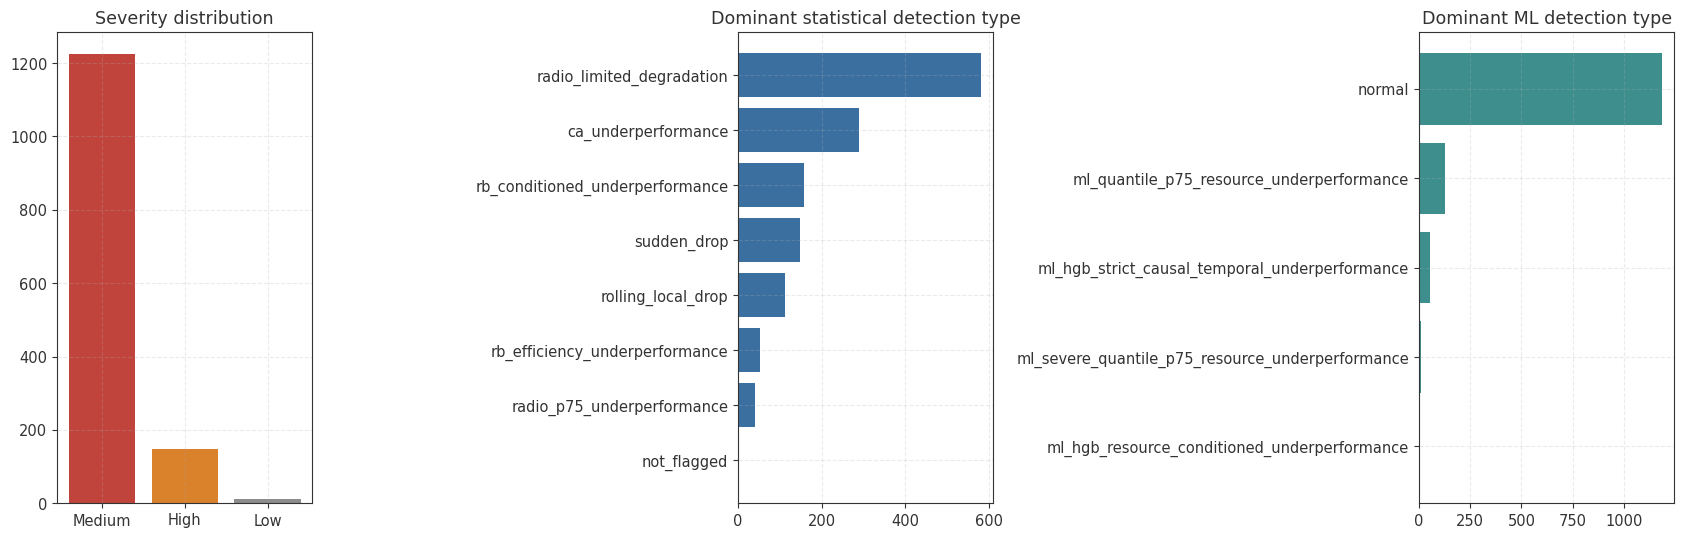

Statistical-only detections (ML says 'normal'): 85.9%


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5.5))

sev_counts = pd.Series([i.get('severity') for i in incidents]).value_counts()
axes[0].bar(sev_counts.index, sev_counts.values, color=[COLORS['red'], COLORS['orange'], COLORS['grey']][:len(sev_counts)])
axes[0].set_title('Severity distribution')

stat_counts = pd.Series([i.get('dominant_statistical_type') for i in incidents]).value_counts()
axes[1].barh(stat_counts.index[::-1], stat_counts.values[::-1], color=COLORS['blue'])
axes[1].set_title('Dominant statistical detection type')

ml_counts = pd.Series([i.get('dominant_ml_type') for i in incidents]).value_counts()
axes[2].barh(ml_counts.index[::-1], ml_counts.values[::-1], color=COLORS['teal'])
axes[2].set_title('Dominant ML detection type')
plt.tight_layout(); plt.show()

print(f"Statistical-only detections (ML says 'normal'): {(ml_counts.get('normal',0))/len(incidents)*100:.1f}%")


## 14. Severity by Root Cause

Which causes tend to be High severity vs Medium/Low.


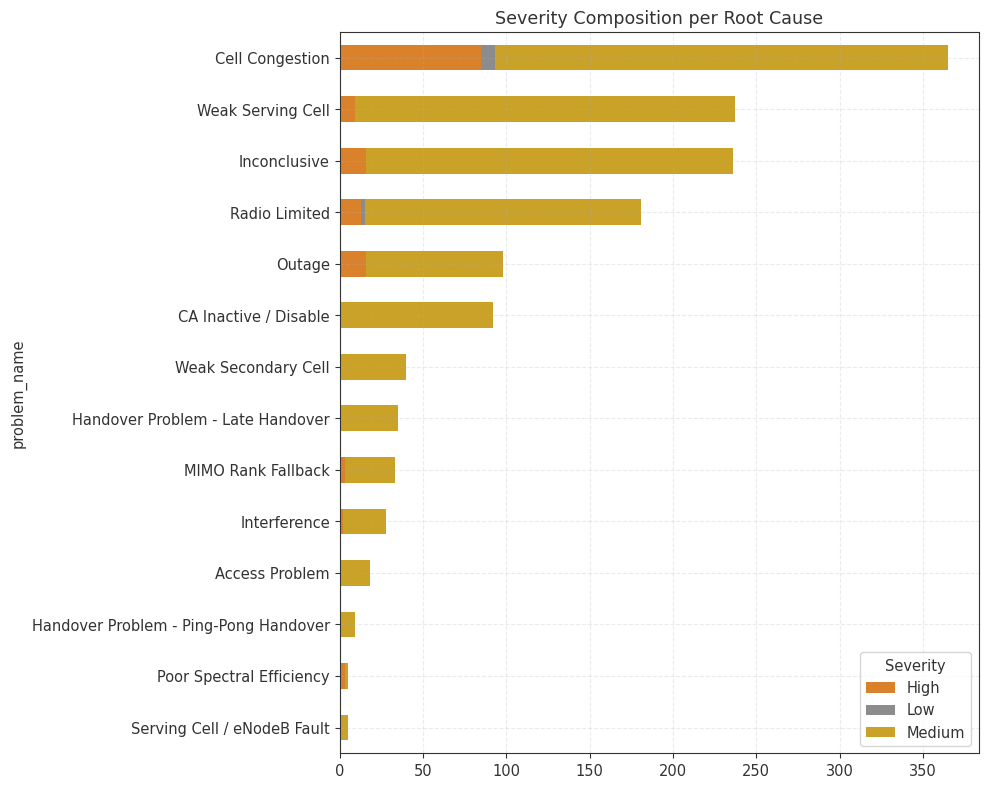

severity,High,Low,Medium
problem_name,,,
Cell Congestion,85,8,272
Weak Serving Cell,9,0,228
Inconclusive,16,0,220
Radio Limited,13,2,166
Outage,16,0,82
CA Inactive / Disable,0,1,91
Weak Secondary Cell,0,0,40
Handover Problem - Late Handover,0,0,35
MIMO Rank Fallback,3,0,30


In [16]:
sev_by_cause = pd.DataFrame({
    'problem_name': [r[1] for r in classification_results],
    'severity': [i.get('severity') for i in incidents],
})
cross = pd.crosstab(sev_by_cause['problem_name'], sev_by_cause['severity'])
cross = cross.loc[cross.sum(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(10, 8))
cross.plot(kind='barh', stacked=True, ax=ax,
           color=[COLORS.get(c.lower(), COLORS['grey']) for c in cross.columns])
ax.invert_yaxis()
ax.set_title('Severity Composition per Root Cause')
ax.legend(title='Severity')
plt.tight_layout(); plt.show()
display(cross)


## 15. Location Reliability

How trustworthy is `approximate_location` across this dataset -- relevant to any future spatial analysis (e.g. a PCI-collision check), and the documented reason a similar check was dropped earlier in this project.


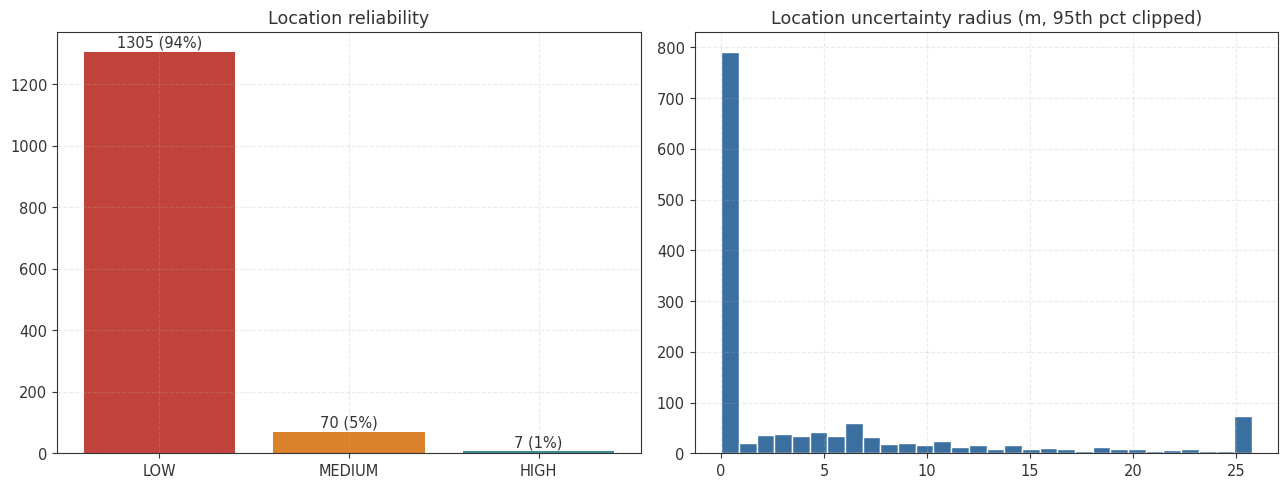

In [17]:
loc_rel = pd.Series([gg(i, 'approximate_location.location_reliability') for i in incidents]).value_counts()
loc_uncertainty = pd.Series([gg(i, 'approximate_location.location_uncertainty_radius_m') for i in incidents]).dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].bar(loc_rel.index, loc_rel.values, color=[COLORS['red'], COLORS['orange'], COLORS['teal']][:len(loc_rel)])
axes[0].set_title('Location reliability')
for i,v in enumerate(loc_rel.values): axes[0].text(i, v+15, f'{v} ({v/len(incidents)*100:.0f}%)', ha='center')

axes[1].hist(loc_uncertainty.clip(upper=loc_uncertainty.quantile(0.95)), bins=30, color=COLORS['blue'], edgecolor='white')
axes[1].set_title('Location uncertainty radius (m, 95th pct clipped)')
plt.tight_layout(); plt.show()


## 16. Per-Cell Hotspot View

Which cells concentrate the most incidents, and what dominates each one.


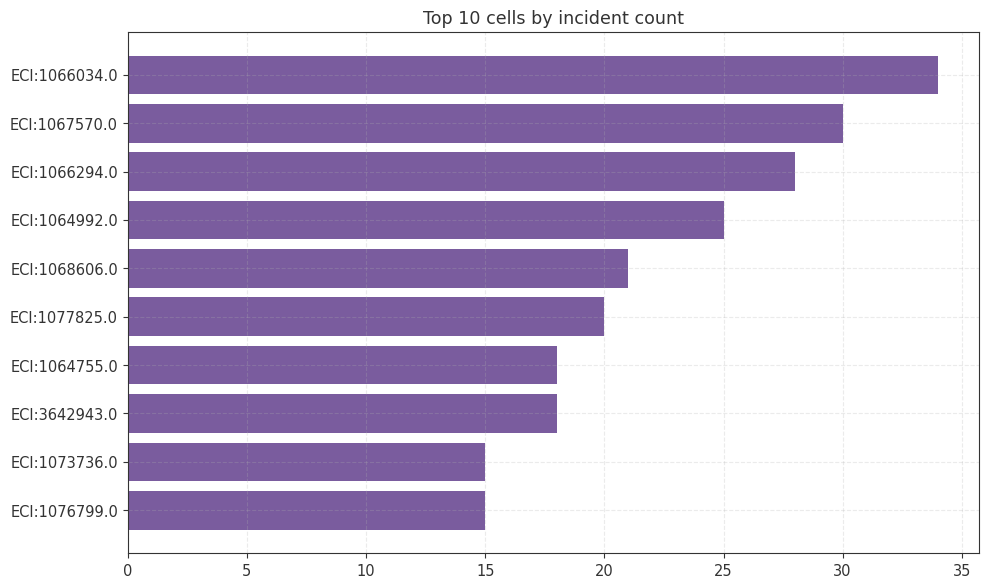

Dominant cause per top cell:
  ECI:1066034.0: 34 incidents, dominant cause = Inconclusive
  ECI:1067570.0: 30 incidents, dominant cause = Inconclusive
  ECI:1066294.0: 28 incidents, dominant cause = Cell Congestion
  ECI:1064992.0: 25 incidents, dominant cause = Radio Limited
  ECI:1068606.0: 21 incidents, dominant cause = Inconclusive
  ECI:1077825.0: 20 incidents, dominant cause = Radio Limited
  ECI:1064755.0: 18 incidents, dominant cause = Inconclusive
  ECI:3642943.0: 18 incidents, dominant cause = Inconclusive
  ECI:1073736.0: 15 incidents, dominant cause = Weak Serving Cell
  ECI:1076799.0: 15 incidents, dominant cause = Cell Congestion


In [18]:
cell_df = pd.DataFrame({
    'serving_cell_key': [i.get('serving_cell_key') for i in incidents],
    'problem_name': [r[1] for r in classification_results],
})
top_cells = cell_df['serving_cell_key'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10,6))
ax.barh([str(c) for c in top_cells.index[::-1]], top_cells.values[::-1], color=COLORS['purple'])
ax.set_title('Top 10 cells by incident count')
plt.tight_layout(); plt.show()

print("Dominant cause per top cell:")
for cell in top_cells.index:
    dominant = cell_df[cell_df['serving_cell_key']==cell]['problem_name'].value_counts().idxmax()
    print(f"  {cell}: {top_cells[cell]} incidents, dominant cause = {dominant}")


## 17. Current Fault-Tree Structure (matches `causes.json`)

A fresh diagram of the classification tree as it stands today -- 7 priority categories, 14 causes.
Unlike the original approved diagram, this one has no PCI/Cell Identity Conflict and no split
Serving/Neighbor Outage (merged into one honest "Outage" category), reflecting every correction made
during this project.


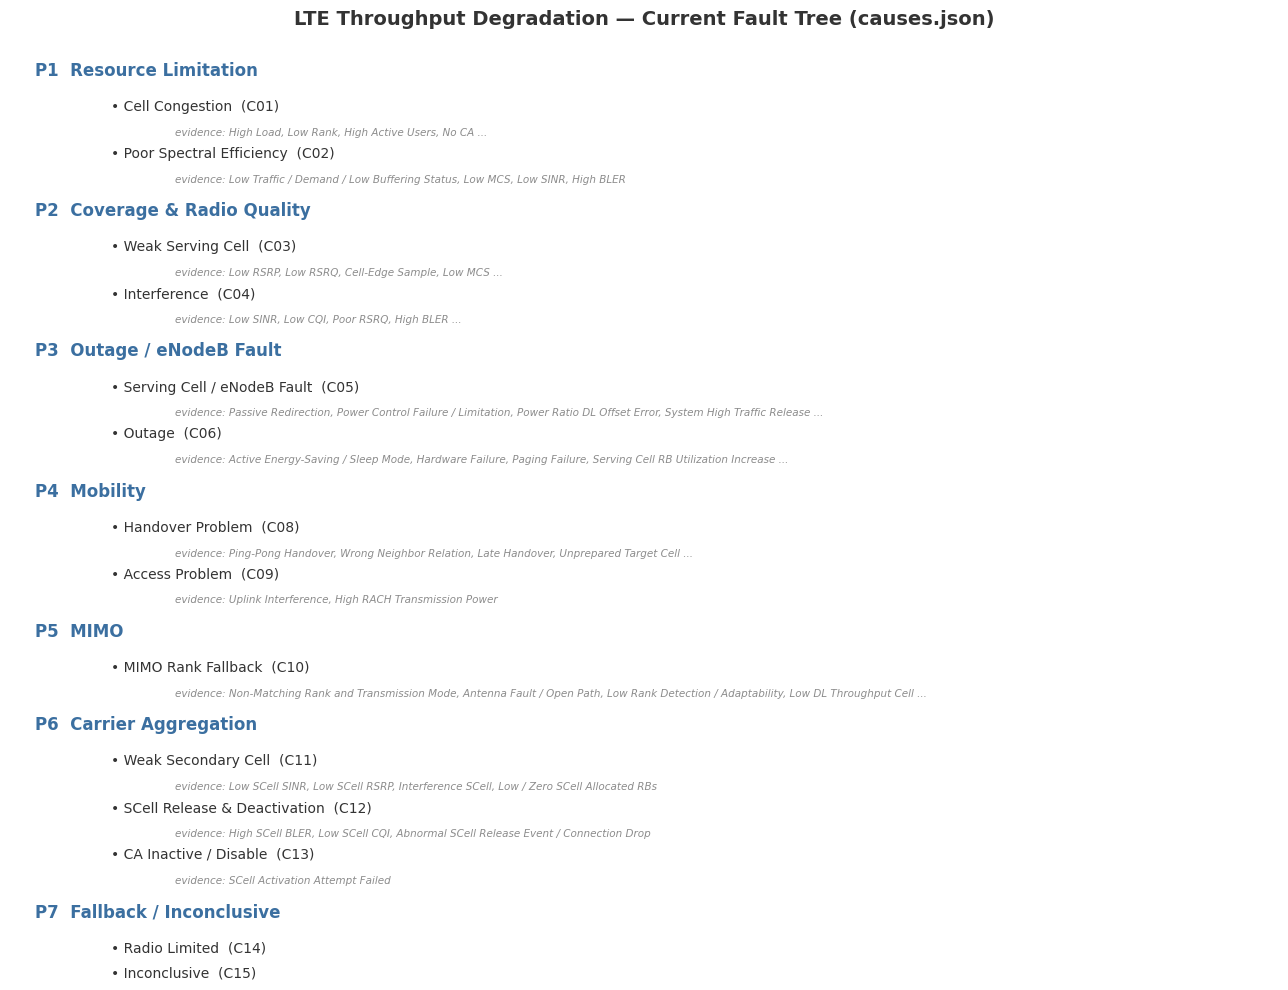

In [19]:
fig, ax = plt.subplots(figsize=(13, 10))
ax.axis('off')

y = 0.97
cat_color = COLORS['blue']
for cat in causes['priority_categories']:
    ax.text(0.02, y, f"P{cat['priority']}  {cat['category']}", fontsize=12, fontweight='bold', color=cat_color,
            transform=ax.transAxes)
    y -= 0.045
    for sc in cat['subcategories']:
        main = next(c for c in sc['causes_list'] if c['id']==sc['parent_id'])
        ax.text(0.08, y, f"• {sc['subcategory']}  ({sc['parent_id']})", fontsize=10, transform=ax.transAxes)
        y -= 0.032
        evidence_names = [c['name'] for c in sc['causes_list'] if c['id'] != sc['parent_id']]
        if evidence_names:
            ax.text(0.13, y, "evidence: " + ", ".join(evidence_names[:4]) + (" ..." if len(evidence_names)>4 else ""),
                    fontsize=7.5, color=COLORS['grey'], transform=ax.transAxes, style='italic')
            y -= 0.028
    y -= 0.015

ax.set_title('LTE Throughput Degradation — Current Fault Tree (causes.json)', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout(); plt.show()


## 18. Summary


In [20]:
print("="*70)
print("SUMMARY -- Incidents Dataset RCA")
print("="*70)
print(f"Total incidents classified: {len(incidents)}")
print(f"Distinct root causes observed: {len(dist)}")
print(f"Top 3 causes: {', '.join(f'{n} ({c})' for n,c in dist.most_common(3))}")
print(f"High severity share: {(pd.Series([i.get('severity') for i in incidents])=='High').mean()*100:.1f}%")
print(f"Incidents needing human review: {sum(1 for i in incidents if i.get('requires_human_review'))}")
print(f"Location reliability LOW: {(pd.Series([gg(i,'approximate_location.location_reliability') for i in incidents])=='LOW').mean()*100:.1f}%")
print()
print("Known structural gaps (documented, not silent):")
for cid in ['C05', 'C12']:
    print(f"  {cid} ({id_to_cause[cid]['name']}): {dist.get(id_to_subcat[cid]['subcategory'], 0) if cid==id_to_subcat[cid]['parent_id'] else 'n/a'} occurrences" )


SUMMARY -- Incidents Dataset RCA
Total incidents classified: 1382
Distinct root causes observed: 14
Top 3 causes: Cell Congestion (365), Weak Serving Cell (237), Inconclusive (236)
High severity share: 10.6%
Incidents needing human review: 4
Location reliability LOW: 94.4%

Known structural gaps (documented, not silent):
  C05 (Cell / Hardware Outage): 5 occurrences
  C12 (SCell Release / CA Inactive Mid-Episode): 0 occurrences
